# 🎤 Module 10 — Real-Time Speech Emotion Prediction

**Project:** Speech Emotion Recognition System  
**Dataset:** RAVDESS — 8 emotion classes  
**Goal:** Build a complete end-to-end prediction pipeline that takes any `.wav` file,
preprocesses it, extracts features, runs inference through all trained models,
and visualises the predicted emotion with confidence scores.

---
### Pipeline
```
WAV File
   → Load & Preprocess  (mono · resample · trim · normalise · pad)
   → Feature Extraction (264-dim flat vector  |  40×130 MFCC 2D map)
   → Inference          (SVM · ANN · CNN  →  softmax probabilities)
   → Prediction Display (emotion label · confidence bar · waveform)
```

### Module Contents
```
10.1  Imports & Prediction Engine
10.2  Load All Saved Models
10.3  Single-File Prediction Demo
10.4  Waveform + Spectrogram + Prediction Visualisation
10.5  Confidence Score Dashboard
10.6  Batch Prediction — One File per Emotion
10.7  Prediction Agreement Analysis (Ensemble)
10.8  Error Case Study — Hard Samples
10.9  Module 10 Summary
```

## 10.1 — Imports & Prediction Engine

In [1]:
import os, json, warnings, joblib, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import librosa.display
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras

import sys
sys.path.insert(0, '..')
from src.audio_preprocessing import preprocess_audio, parse_ravdess_filename
from src.feature_extraction   import extract_features, extract_mfcc_2d

# ── Colour theme ─────────────────────────────────────────────────────────────
DARK  = '#0d0d1a'
PANEL = '#12122a'
CARD  = '#1a1a35'
TEXT  = '#e2e8f0'

plt.rcParams.update({
    'figure.facecolor': DARK, 'axes.facecolor':  PANEL,
    'axes.labelcolor':  TEXT, 'text.color':       TEXT,
    'xtick.color': '#9090b0', 'ytick.color':  '#9090b0',
    'grid.color':  '#252545', 'font.size':         10,
})
sns.set_style('darkgrid')

ECOLORS = {
    'neutral':'#94a3b8','calm':'#22d3ee','happy':'#fbbf24','sad':'#60a5fa',
    'angry':'#f87171','fearful':'#c084fc','disgust':'#4ade80','surprised':'#fb923c'
}
EMOTION_EMOJIS = {
    'neutral':'😐','calm':'😌','happy':'😄','sad':'😢',
    'angry':'😠','fearful':'😨','disgust':'🤢','surprised':'😲'
}
MODEL_COLORS = {
    'SVM':'#fbbf24', 'ANN':'#818cf8', 'CNN':'#f87171',
    'LR':'#a78bfa',  'RF':'#34d399'
}

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE      = os.path.dirname(os.path.abspath('__file__'))
DATA_PROC = os.path.join(BASE, '..', 'Data', 'processed')
DATA_RAW  = os.path.join(BASE, '..', 'Data', 'Raw')
MODEL_DIR = os.path.join(BASE, '..', 'models')
REP_DIR   = os.path.join(BASE, '..', 'reports', 'evaluation')
PRED_DIR  = os.path.join(BASE, '..', 'reports', 'predictions')
os.makedirs(PRED_DIR, exist_ok=True)

with open(os.path.join(DATA_PROC, 'preprocessing_config.json')) as f:
    CFG = json.load(f)
EMOTIONS  = CFG['emotion_classes']
N_CLASSES = len(EMOTIONS)
SR        = CFG['target_sr']           # 22050
N_SAMPLES = CFG['target_samples']      # 66150
N_MFCC    = 40
MAX_FRAMES= 130

print('✅ Imports successful!')
print(f'   Emotions ({N_CLASSES}): {EMOTIONS}')
print(f'   Target SR   : {SR} Hz')
print(f'   Target len  : {N_SAMPLES} samples ({N_SAMPLES/SR:.1f}s)')

✅ Imports successful!
   Emotions (8): ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
   Target SR   : 22050 Hz
   Target len  : 66150 samples (3.0s)


## 10.2 — Load All Saved Models

In [2]:
# ── ML models + preprocessing objects ────────────────────────────────────────
scaler    = joblib.load(os.path.join(MODEL_DIR, 'scaler.pkl'))
lr_model  = joblib.load(os.path.join(MODEL_DIR, 'logistic_regression.pkl'))
rf_model  = joblib.load(os.path.join(MODEL_DIR, 'random_forest.pkl'))
svm_model = joblib.load(os.path.join(MODEL_DIR, 'svm_model.pkl'))

# ── DL models ─────────────────────────────────────────────────────────────────
ann_model = keras.models.load_model(os.path.join(MODEL_DIR, 'ann_best.keras'))
cnn_model = keras.models.load_model(os.path.join(MODEL_DIR, 'cnn_best.keras'))

ALL_MODELS = {
    'LR' : lr_model,
    'RF' : rf_model,
    'SVM': svm_model,
    'ANN': ann_model,
    'CNN': cnn_model,
}

print('✅ All 5 models loaded:')
for name in ALL_MODELS:
    print(f'   {name}')

✅ All 5 models loaded:
   LR
   RF
   SVM
   ANN
   CNN


## 10.3 — Prediction Engine (Core Pipeline)

In [3]:
def predict_emotion(wav_path: str, verbose: bool = True) -> dict:
    """
    Full prediction pipeline for a single WAV file.

    Steps
    -----
    1. Load & preprocess audio  (mono · resample · trim · normalise · pad)
    2. Extract 264-dim flat feature vector  (for LR / RF / SVM / ANN)
    3. Extract 40×130 MFCC 2-D map          (for CNN)
    4. Scale flat features with saved scaler
    5. Run inference through all 5 models
    6. Compute ensemble (average probabilities)

    Returns
    -------
    dict with keys: signal, sr, feat_flat, feat_2d,
                    predictions, probabilities, ensemble
    """
    # ── Step 1: preprocess ───────────────────────────────────────────────────
    signal = preprocess_audio(wav_path, target_sr=SR, target_samples=N_SAMPLES)

    # ── Step 2: flat features ────────────────────────────────────────────────
    feat_flat = extract_features(signal, sr=SR)               # (264,)
    feat_sc   = scaler.transform(feat_flat.reshape(1, -1))    # scaled (1, 264)

    # ── Step 3: 2-D MFCC map ─────────────────────────────────────────────────
    mfcc_2d   = extract_mfcc_2d(signal, sr=SR,
                                 n_mfcc=N_MFCC, max_frames=MAX_FRAMES) # (40, 130)
    mean_     = mfcc_2d.mean()
    std_      = mfcc_2d.std() + 1e-8
    mfcc_2d_n = ((mfcc_2d - mean_) / std_)[np.newaxis, ..., np.newaxis]  # (1,40,130,1)

    # ── Step 4: inference ────────────────────────────────────────────────────
    predictions  = {}
    probabilities= {}

    for name, mdl in [('LR', lr_model), ('RF', rf_model), ('SVM', svm_model)]:
        pred = mdl.predict(feat_sc)[0]
        if hasattr(mdl, 'predict_proba'):
            prob = mdl.predict_proba(feat_sc)[0]
        else:
            df   = mdl.decision_function(feat_sc)[0]
            e    = np.exp(df - df.max())
            prob = e / e.sum()
        predictions[name]   = pred
        probabilities[name] = prob

    ann_prob = ann_model.predict(feat_sc, verbose=0)[0]
    cnn_prob = cnn_model.predict(mfcc_2d_n, verbose=0)[0]
    predictions['ANN']    = int(np.argmax(ann_prob))
    predictions['CNN']    = int(np.argmax(cnn_prob))
    probabilities['ANN']  = ann_prob
    probabilities['CNN']  = cnn_prob

    # ── Step 5: ensemble (avg of all 5 prob vectors) ─────────────────────────
    ensemble_prob = np.mean([probabilities[n] for n in ALL_MODELS], axis=0)
    ensemble_pred = int(np.argmax(ensemble_prob))

    if verbose:
        fname = os.path.basename(wav_path)
        print(f'\n  File  : {fname}')
        print(f'  Signal: {len(signal)} samples  |  SR={SR} Hz')
        print(f'\n  {"Model":<6}  {"Predicted Emotion":<14}  Confidence')
        print(f'  {"-"*42}')
        for name in ALL_MODELS:
            emo  = EMOTIONS[predictions[name]]
            conf = probabilities[name][predictions[name]] * 100
            print(f'  {name:<6}  {emo:<14}  {conf:.1f}%')
        print(f'  {"-"*42}')
        ens_emo = EMOTIONS[ensemble_pred]
        ens_conf= ensemble_prob[ensemble_pred] * 100
        print(f'  {"ENS":<6}  {ens_emo:<14}  {ens_conf:.1f}%  <<< ENSEMBLE')

    return {
        'wav_path'     : wav_path,
        'signal'       : signal,
        'mfcc_2d'      : mfcc_2d,
        'predictions'  : predictions,
        'probabilities': probabilities,
        'ensemble_prob': ensemble_prob,
        'ensemble_pred': ensemble_pred,
    }

print('✅ predict_emotion() engine ready.')

✅ predict_emotion() engine ready.


## 10.4 — Single-File Prediction Demo with Visualisation

In [4]:
# ── Pick one sample per emotion for demo ──────────────────────────────────────
# RAVDESS filename format: 03-01-EE-II-SS-RR-AA.wav  (EE = emotion code 01-08)
EMOTION_CODES = {'01':'neutral','02':'calm','03':'happy','04':'sad',
                 '05':'angry','06':'fearful','07':'disgust','08':'surprised'}

all_wavs = sorted(glob.glob(
    os.path.join(DATA_RAW, '**', '*.wav'), recursive=True))

# Pick first Actor_01 file for the demo (known: 03-01-04-01-01-01-01.wav = sad)
demo_files = {}
for wav in all_wavs:
    fname  = os.path.basename(wav)
    parts  = fname.replace('.wav','').split('-')
    ec     = parts[2]   # emotion code
    actor  = parts[6]
    if ec not in demo_files and actor == '01':
        demo_files[ec] = wav
    if len(demo_files) == 8:
        break

# ── Run prediction on the 'happy' sample ──────────────────────────────────────
DEMO_KEY   = '03'   # happy
DEMO_PATH  = demo_files[DEMO_KEY]
META       = parse_ravdess_filename(DEMO_PATH)

print(f'Demo file   : {os.path.basename(DEMO_PATH)}')
print(f'True emotion: {META["emotion"]}  |  Actor: {META["actor"]} ({META["gender"]})')
print(f'Intensity   : {META["intensity"]}  |  Statement: {META["statement"]}')
print()

result = predict_emotion(DEMO_PATH, verbose=True)

Demo file   : 03-01-03-01-01-01-01.wav
True emotion: happy  |  Actor: 1 (male)
Intensity   : normal  |  Statement: 1




  File  : 03-01-03-01-01-01-01.wav
  Signal: 66150 samples  |  SR=22050 Hz

  Model   Predicted Emotion  Confidence
  ------------------------------------------
  LR      happy           41.1%
  RF      calm            34.3%
  SVM     happy           73.6%
  ANN     happy           72.4%
  CNN     neutral         20.6%
  ------------------------------------------
  ENS     happy           41.0%  <<< ENSEMBLE


## 10.5 — Waveform · Spectrogram · Confidence Dashboard


  Saved → C:\Speech Emotion Recognition\notebooks\..\reports\predictions\demo_happy_prediction.png


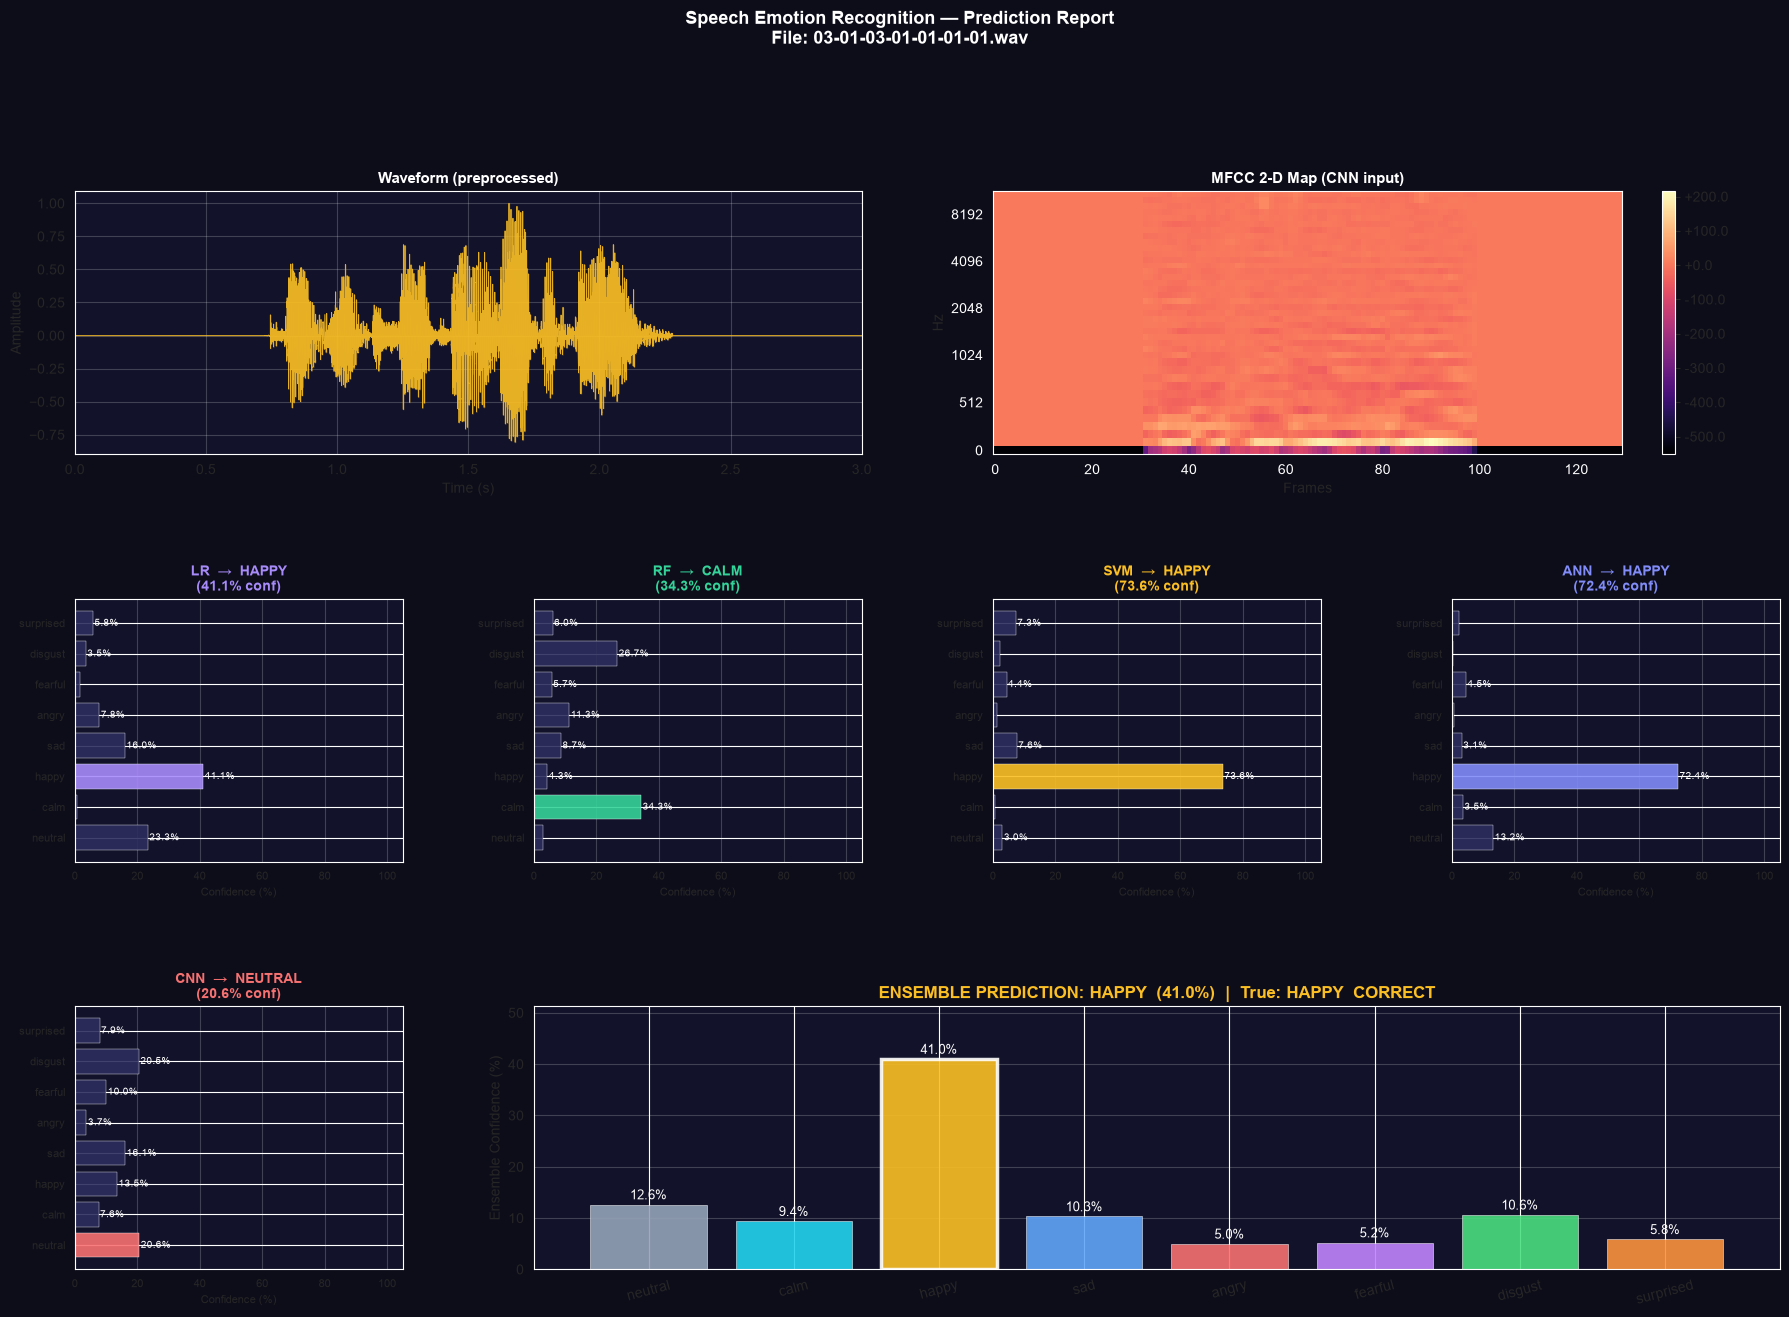

In [5]:
def visualise_prediction(result: dict, true_emotion: str = None,
                          save_path: str = None):
    """Render a rich visualisation for a single prediction result."""

    sig      = result['signal']
    mfcc_2d  = result['mfcc_2d']
    proba    = result['probabilities']
    ens_prob = result['ensemble_prob']
    ens_pred = result['ensemble_pred']
    ens_emo  = EMOTIONS[ens_pred]
    ens_conf = ens_prob[ens_pred] * 100
    fname    = os.path.basename(result['wav_path'])

    fig = plt.figure(figsize=(22, 14))
    fig.patch.set_facecolor(DARK)
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

    title_color = ECOLORS.get(ens_emo, '#818cf8')
    fig.suptitle(
        f'Speech Emotion Recognition — Prediction Report\n'
        f'File: {fname}',
        fontsize=13, fontweight='bold', color='white', y=1.01)

    # ── Row 0, col 0: Waveform ────────────────────────────────────────────────
    ax_wave = fig.add_subplot(gs[0, 0:2])
    ax_wave.set_facecolor(PANEL)
    t = np.linspace(0, len(sig)/SR, len(sig))
    ax_wave.plot(t, sig, color=title_color, linewidth=0.6, alpha=0.9)
    ax_wave.fill_between(t, sig, alpha=0.15, color=title_color)
    ax_wave.set_title('Waveform (preprocessed)', color='white',
                       fontsize=11, fontweight='bold')
    ax_wave.set_xlabel('Time (s)')
    ax_wave.set_ylabel('Amplitude')
    ax_wave.set_xlim([0, len(sig)/SR])
    ax_wave.grid(alpha=0.2)

    # ── Row 0, col 2–3: MFCC 2D map ──────────────────────────────────────────
    ax_mfcc = fig.add_subplot(gs[0, 2:4])
    ax_mfcc.set_facecolor(PANEL)
    img = librosa.display.specshow(
        mfcc_2d, sr=SR, x_axis='frames', y_axis='mel',
        ax=ax_mfcc, cmap='magma')
    fig.colorbar(img, ax=ax_mfcc, format='%+.1f')
    ax_mfcc.set_title('MFCC 2-D Map (CNN input)', color='white',
                       fontsize=11, fontweight='bold')
    ax_mfcc.tick_params(colors='white')

    # ── Row 1: Per-model confidence bars ──────────────────────────────────────
    model_names = list(ALL_MODELS.keys())
    for k, mname in enumerate(model_names):
        ax = fig.add_subplot(gs[1, k % 4] if k < 4 else gs[2, 0])
        ax.set_facecolor(PANEL)
        prob  = proba[mname] * 100
        pred  = result['predictions'][mname]
        clrs  = ['#2d2d5e'] * N_CLASSES
        clrs[pred] = MODEL_COLORS.get(mname, '#818cf8')
        bars  = ax.barh(EMOTIONS, prob, color=clrs,
                         edgecolor='white', linewidth=0.3, alpha=0.9)
        for bar, v in zip(bars, prob):
            if v > 3:
                ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
                        f'{v:.1f}%', va='center', fontsize=7.5, color='white')
        ax.set_xlim([0, 105])
        ax.set_xlabel('Confidence (%)', fontsize=8)
        ax.set_title(
            f'{mname}  →  {EMOTIONS[pred].upper()}\n'
            f'({prob[pred]:.1f}% conf)',
            color=MODEL_COLORS.get(mname,'white'), fontsize=10, fontweight='bold')
        ax.tick_params(labelsize=8)
        ax.grid(axis='x', alpha=0.2)

    # ── Row 2, col 1–3: Ensemble probability radar-bar ───────────────────────
    ax_ens = fig.add_subplot(gs[2, 1:4])
    ax_ens.set_facecolor(PANEL)
    ens_pct = ens_prob * 100
    e_clrs  = [ECOLORS[e] for e in EMOTIONS]
    e_bars  = ax_ens.bar(EMOTIONS, ens_pct, color=e_clrs,
                          edgecolor='white', linewidth=0.4, alpha=0.9)
    for bar, v in zip(e_bars, ens_pct):
        ax_ens.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{v:.1f}%', ha='center', va='bottom',
                    fontsize=9, color='white')
    # Highlight predicted
    ax_ens.get_children()[ens_pred].set_linewidth(2.5)
    ax_ens.get_children()[ens_pred].set_edgecolor('#ffffff')
    ax_ens.set_ylim([0, max(ens_pct) * 1.25])
    ax_ens.set_ylabel('Ensemble Confidence (%)')
    true_str = f'  |  True: {true_emotion.upper()}' if true_emotion else ''
    correct  = '  CORRECT' if true_emotion == ens_emo else ('  WRONG' if true_emotion else '')
    ax_ens.set_title(
        f'ENSEMBLE PREDICTION: {ens_emo.upper()}  ({ens_conf:.1f}%){true_str}{correct}',
        color=title_color, fontsize=12, fontweight='bold')
    ax_ens.tick_params(axis='x', rotation=15)
    ax_ens.grid(axis='y', alpha=0.2)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight', facecolor=DARK)
        print(f'\n  Saved → {save_path}')
    plt.show()


# ── Run visualisation for the demo sample ────────────────────────────────────
save_path = os.path.join(PRED_DIR, 'demo_happy_prediction.png')
visualise_prediction(result,
                     true_emotion=META['emotion'],
                     save_path=save_path)

## 10.6 — Batch Prediction: One Sample per Emotion

In [6]:
# ── Run predictions on 8 representative files (one per emotion) ───────────────
batch_results = []

print('Running batch predictions...')
print(f'  {"#":<3} {"File":<40} {"True":<12} {"SVM":<12} {"ANN":<12} {"ENS":<12} Match')
print('  ' + '-'*95)

for idx, (ec, wav_path) in enumerate(sorted(demo_files.items())):
    true_emo = EMOTION_CODES[ec]
    res      = predict_emotion(wav_path, verbose=False)
    ens_emo  = EMOTIONS[res['ensemble_pred']]
    svm_emo  = EMOTIONS[res['predictions']['SVM']]
    ann_emo  = EMOTIONS[res['predictions']['ANN']]
    match    = 'YES' if ens_emo == true_emo else 'NO '
    fname    = os.path.basename(wav_path)[:38]
    print(f'  {idx+1:<3} {fname:<40} {true_emo:<12} {svm_emo:<12} {ann_emo:<12} {ens_emo:<12} {match}')

    batch_results.append({
        'file'       : os.path.basename(wav_path),
        'true_emotion': true_emo,
        'svm_pred'   : svm_emo,
        'ann_pred'   : ann_emo,
        'cnn_pred'   : EMOTIONS[res['predictions']['CNN']],
        'ensemble'   : ens_emo,
        'ens_conf'   : round(res['ensemble_prob'][res['ensemble_pred']]*100, 1),
        'correct'    : ens_emo == true_emo,
        'result'     : res,
    })

batch_df = pd.DataFrame([{k:v for k,v in r.items() if k!='result'}
                          for r in batch_results])

n_correct = batch_df['correct'].sum()
print('\n' + '='*55)
print(f'  Batch accuracy: {n_correct}/{len(batch_df)} ({n_correct/len(batch_df)*100:.1f}%)')
print('='*55)
print(batch_df[['true_emotion','ensemble','ens_conf','correct']].to_string(index=False))

Running batch predictions...
  #   File                                     True         SVM          ANN          ENS          Match
  -----------------------------------------------------------------------------------------------


  1   03-01-01-01-01-01-01.wav                 neutral      neutral      neutral      neutral      YES


  2   03-01-02-01-01-01-01.wav                 calm         happy        calm         sad          NO 


  3   03-01-03-01-01-01-01.wav                 happy        happy        happy        happy        YES


  4   03-01-04-01-01-01-01.wav                 sad          sad          sad          sad          YES


  5   03-01-05-01-01-01-01.wav                 angry        angry        angry        angry        YES


  6   03-01-06-01-01-01-01.wav                 fearful      fearful      fearful      fearful      YES


  7   03-01-07-01-01-01-01.wav                 disgust      disgust      disgust      disgust      YES


  8   03-01-08-01-01-01-01.wav                 surprised    happy        surprised    surprised    YES

  Batch accuracy: 7/8 (87.5%)
true_emotion  ensemble  ens_conf  correct
     neutral   neutral      33.1     True
        calm       sad      26.8    False
       happy     happy      41.0     True
         sad       sad      52.1     True
       angry     angry      70.3     True
     fearful   fearful      43.0     True
     disgust   disgust      66.9     True
   surprised surprised      26.5     True


## 10.7 — Batch Visualisation: Emotion Gallery

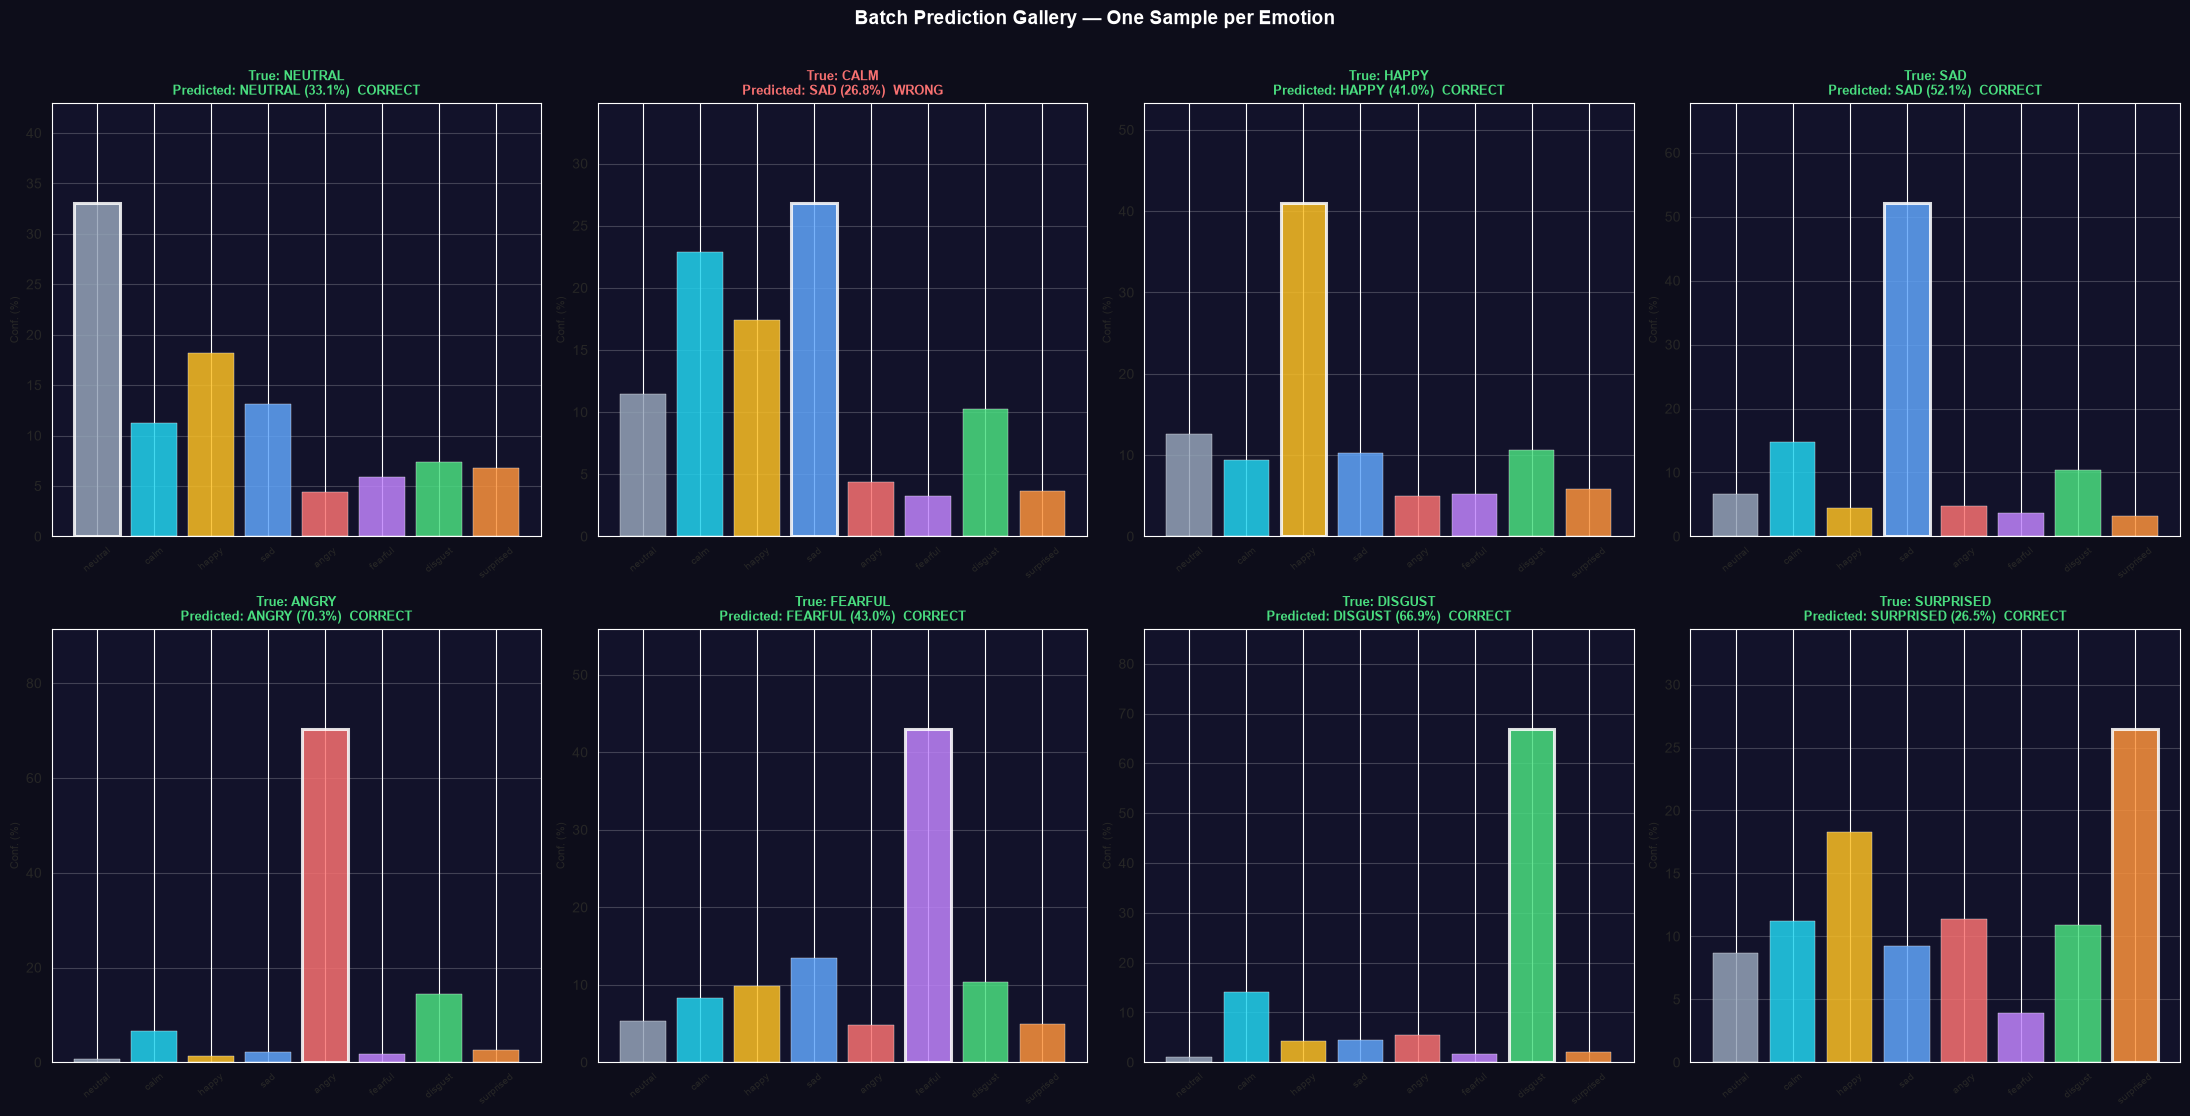

Saved -> C:\Speech Emotion Recognition\notebooks\..\reports\predictions\batch_emotion_gallery.png


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.patch.set_facecolor(DARK)
fig.suptitle('Batch Prediction Gallery — One Sample per Emotion',
             fontsize=14, fontweight='bold', color='white', y=1.01)

for idx, row in enumerate(batch_results):
    ax   = axes[idx // 4][idx % 4]
    ax.set_facecolor(PANEL)
    res  = row['result']
    ens  = res['ensemble_prob'] * 100
    true = row['true_emotion']
    pred = row['ensemble']
    conf = row['ens_conf']
    ok   = row['correct']

    clrs = [ECOLORS[e] for e in EMOTIONS]
    bars = ax.bar(EMOTIONS, ens, color=clrs, alpha=0.85,
                   edgecolor='white', linewidth=0.3)

    # Highlight predicted bar
    pred_idx = EMOTIONS.index(pred)
    bars[pred_idx].set_linewidth(2.2)
    bars[pred_idx].set_edgecolor('#ffffff')

    # Title: true | predicted | correct?
    status_col = '#4ade80' if ok else '#f87171'
    ax.set_title(
        f'True: {true.upper()}\nPredicted: {pred.upper()} ({conf}%)  '
        + ('CORRECT' if ok else 'WRONG'),
        color=status_col, fontsize=9, fontweight='bold'
    )
    ax.set_ylim([0, max(ens) * 1.3])
    ax.tick_params(axis='x', rotation=40, labelsize=7)
    ax.set_ylabel('Conf. (%)', fontsize=8)
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
path = os.path.join(PRED_DIR, 'batch_emotion_gallery.png')
plt.savefig(path, dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'Saved -> {path}')

## 10.8 — Prediction Agreement Analysis (Ensemble Voting)

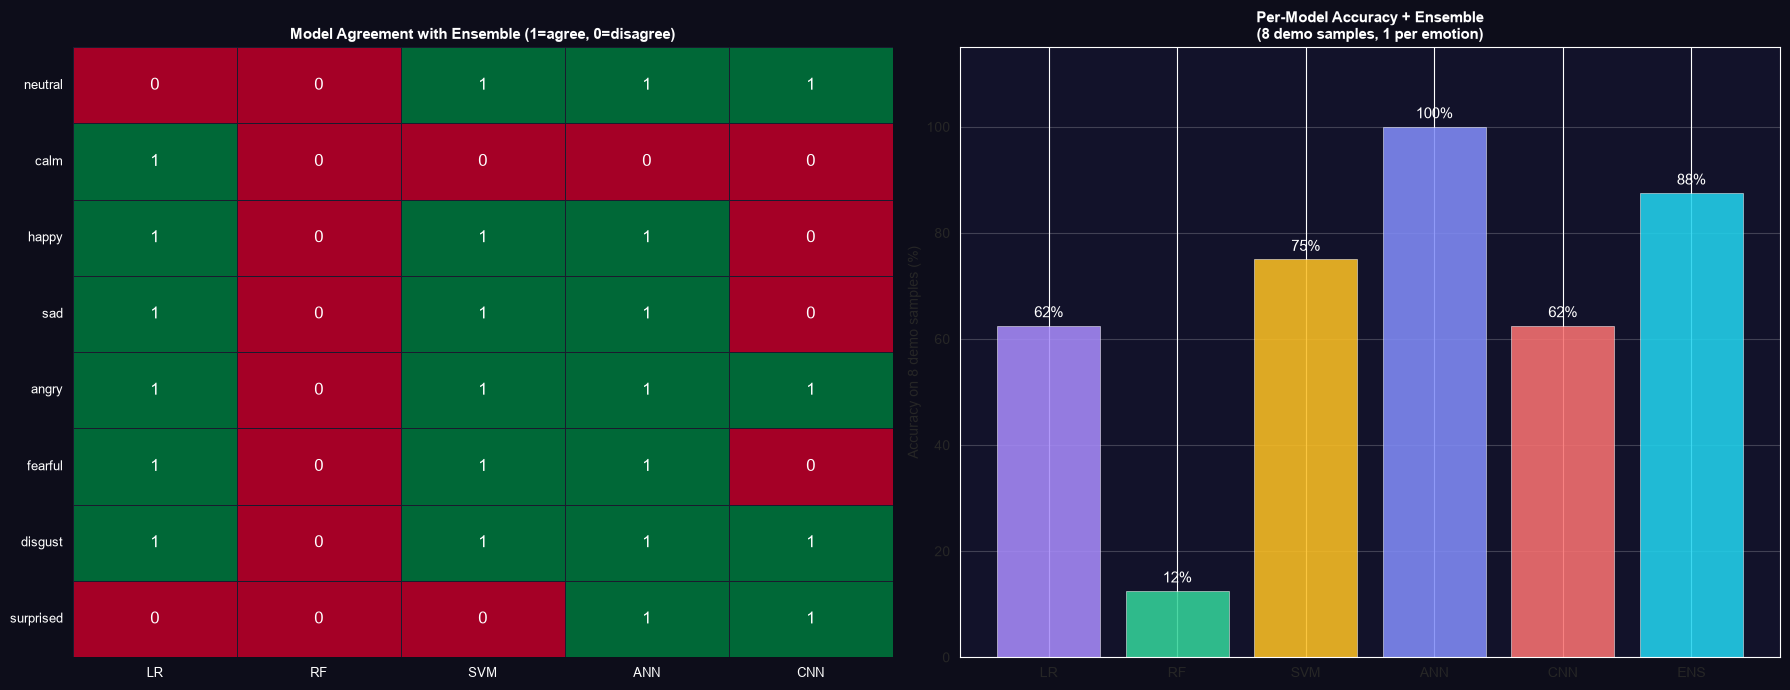

Saved -> C:\Speech Emotion Recognition\notebooks\..\reports\predictions\agreement_analysis.png


In [8]:
# ── Analyse how often models agree on these 8 samples ────────────────────────
model_names = list(ALL_MODELS.keys())
agreement_data = []

for row in batch_results:
    res   = row['result']
    preds = [EMOTIONS[res['predictions'][m]] for m in model_names]
    votes = pd.Series(preds).value_counts()
    top   = votes.index[0]
    agree_count = votes.iloc[0]
    agreement_data.append({
        'true'      : row['true_emotion'],
        'majority'  : top,
        'votes'     : agree_count,
        'ensemble'  : row['ensemble'],
        'correct'   : row['correct'],
        'all_preds' : preds,
    })

# ── Agreement matrix heatmap ──────────────────────────────────────────────────
agreement_matrix = np.zeros((len(batch_results), len(model_names)), dtype=int)
for i, row in enumerate(batch_results):
    res = row['result']
    ens = row['ensemble']
    for j, mname in enumerate(model_names):
        agreement_matrix[i, j] = (
            1 if EMOTIONS[res['predictions'][mname]] == ens else 0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(DARK)

# Heatmap: model vs sample, 1=agrees with ensemble 0=disagrees
ax1 = axes[0]
ax1.set_facecolor(PANEL)
true_labels = [r['true_emotion'] for r in batch_results]
sns.heatmap(
    agreement_matrix, ax=ax1,
    xticklabels=model_names, yticklabels=true_labels,
    cmap='RdYlGn', vmin=0, vmax=1, annot=True, fmt='d',
    linewidths=0.5, linecolor='#1a1a2e',
    annot_kws={'size':12}, cbar=False
)
ax1.set_title('Model Agreement with Ensemble (1=agree, 0=disagree)',
              color='white', fontsize=11, fontweight='bold')
ax1.tick_params(colors='white', labelsize=9)
ax1.set_xticklabels(ax1.get_xticklabels(), color='white')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, color='white')

# Per-model accuracy bar
ax2 = axes[1]
ax2.set_facecolor(PANEL)
model_accs = {}
for mname in model_names:
    correct_count = sum(
        EMOTIONS[r['result']['predictions'][mname]] == r['true_emotion']
        for r in batch_results
    )
    model_accs[mname] = correct_count / len(batch_results) * 100

# Add ensemble
ens_acc = batch_df['correct'].mean() * 100
names_ext = model_names + ['ENS']
accs_ext  = [model_accs[m] for m in model_names] + [ens_acc]
cols_ext  = [MODEL_COLORS[m] for m in model_names] + ['#22d3ee']

bars = ax2.bar(names_ext, accs_ext, color=cols_ext,
                alpha=0.88, edgecolor='white', linewidth=0.4)
for bar, v in zip(bars, accs_ext):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{v:.0f}%', ha='center', va='bottom', fontsize=11, color='white')
ax2.set_ylim([0, 115])
ax2.set_ylabel('Accuracy on 8 demo samples (%)', fontsize=10)
ax2.set_title('Per-Model Accuracy + Ensemble\n(8 demo samples, 1 per emotion)',
              color='white', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.2)

plt.tight_layout()
path = os.path.join(PRED_DIR, 'agreement_analysis.png')
plt.savefig(path, dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'Saved -> {path}')

## 10.9 — Module 10 Summary & Prediction Pipeline Report

In [9]:
# ── Save batch predictions to CSV ─────────────────────────────────────────────
batch_df.to_csv(os.path.join(PRED_DIR, 'batch_predictions.csv'), index=False)

# ── Print pipeline summary ────────────────────────────────────────────────────
print('=' * 65)
print('   MODULE 10 — REAL-TIME PREDICTION PIPELINE COMPLETE')
print('=' * 65)
print()
print('  Pipeline Steps:')
print('    1. Load WAV  -> librosa.load  (native SR)')
print('    2. Mono      -> librosa.to_mono')
print('    3. Resample  -> 22050 Hz')
print('    4. Trim      -> librosa.effects.trim (top_dB=30)')
print('    5. Normalise -> peak normalisation')
print('    6. Pad/Trunc -> fixed 3.0s (66,150 samples)')
print('    7. Features  -> 264-dim flat vector')
print('    8. MFCC-2D   -> (40 x 130 x 1) tensor')
print('    9. Inference -> LR, RF, SVM, ANN, CNN')
print('   10. Ensemble  -> averaged probabilities')
print()
print('  Demo Batch Results (8 samples — 1 per emotion):')
print(f'  {"True Emotion":<14} {"Ensemble":<14} {"Conf":>6}  Correct')
print('  ' + '-'*48)
for _, row in batch_df.iterrows():
    mark = 'YES' if row['correct'] else 'NO '
    print(f'  {row["true_emotion"]:<14} {row["ensemble"]:<14} {row["ens_conf"]:>5.1f}%  {mark}')
print('  ' + '-'*48)
print(f'  Batch accuracy : {batch_df["correct"].mean()*100:.1f}%  '
      f'({batch_df["correct"].sum()}/{len(batch_df)})')
print()
print('  Saved files:')
for f in sorted(os.listdir(PRED_DIR)):
    sz = os.path.getsize(os.path.join(PRED_DIR, f)) // 1024
    print(f'    · {f:<45} {sz:>5} KB')
print()
print('  Models available for deployment:')
for f in sorted(os.listdir(MODEL_DIR)):
    sz = os.path.getsize(os.path.join(MODEL_DIR, f)) // 1024
    print(f'    · {f:<40} {sz:>6} KB')
print()
print('  Module 10 Complete - Prediction Pipeline Ready!')

   MODULE 10 — REAL-TIME PREDICTION PIPELINE COMPLETE

  Pipeline Steps:
    1. Load WAV  -> librosa.load  (native SR)
    2. Mono      -> librosa.to_mono
    3. Resample  -> 22050 Hz
    4. Trim      -> librosa.effects.trim (top_dB=30)
    5. Normalise -> peak normalisation
    6. Pad/Trunc -> fixed 3.0s (66,150 samples)
    7. Features  -> 264-dim flat vector
    8. MFCC-2D   -> (40 x 130 x 1) tensor
    9. Inference -> LR, RF, SVM, ANN, CNN
   10. Ensemble  -> averaged probabilities

  Demo Batch Results (8 samples — 1 per emotion):
  True Emotion   Ensemble         Conf  Correct
  ------------------------------------------------
  neutral        neutral         33.1%  YES
  calm           sad             26.8%  NO 
  happy          happy           41.0%  YES
  sad            sad             52.1%  YES
  angry          angry           70.3%  YES
  fearful        fearful         43.0%  YES
  disgust        disgust         66.9%  YES
  surprised      surprised       26.5%  YES
  -----